# Fig. 7 and S7: AML mosaic integration with mutation heads

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/reproducibility/api/fig7_aml.ipynb)

Paired AML CITE-seq (Knorr et al. 2023) trains the RNA↔protein bridge. Two cohorts that were never measured together are then projected into that frozen bridge: van Galen et al. (2019) scRNA-seq through the RNA encoder and Demaree et al. (2021) DAb-seq through the protein encoder.

This tutorial follows the manuscript analysis more closely than the earlier API draft:

- DAb genotype truth is read from the **variant-specific columns already present in the original DAb `.obs`** (for example `NPM1 W288fs`, `DNMT3A R882H`, and `FLT3-ITD`) and collapsed to gene-level mutation targets.
- van Galen truth is derived from `MutTranscripts` / `WtTranscripts`.
- DAb contributes observed genotype labels only for the genes actually assayed there; unmeasured genes remain masked rather than being treated as wild type.
- mutation-head train/validation/test masks are group-aware: whole van Galen patients and DAb-seq experiments are held out. The article evaluated the heads with cell-level splits (see its Discussion), so this is a stricter test of generalization to new individuals, and scores are expected to be lower than cell-level ones.
- the CITE bridge is retained as a replay set during supervised refinement.
- after refinement, embeddings are recomputed for **all four blocks** (CITE RNA, CITE ADT, van Galen RNA, DAb ADT), and mutation probabilities are projected across the complete joint latent.

The public UniVI 1.1 API is used for preprocessing, training, encoding, and refinement, so exact numerical values can differ slightly from the archived manuscript notebook.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.1" "pandas==2.2.3"

In [2]:
import re

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch

from sklearn.metrics import average_precision_score, roc_auc_score

import univi.datasets as uds
from univi import (
    ClassHeadConfig,
    ModalityConfig,
    RefinementConfig,
    TrainingConfig,
    UniVIConfig,
    UniVIMultiModalVAE,
    UniVIRefiner,
    UniVITrainer,
    predict_heads_adata,
)
from univi.preprocessing import ADTPreprocessor, RNAPreprocessor
from univi.utils.seed import set_seed
from univi.workflows import make_loader, stack_embeddings

device = (
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
set_seed(0)
print("device:", device)

device: cuda


C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 3000
REFINE_EPOCHS = 300

# Cross-cohort mutation vocabulary used by the manuscript analysis.
GENES = [
    "NPM1",
    "DNMT3A",
    "FLT3",
    "TP53",
    "NRAS",
    "TET2",
    "IDH2",
]

# The DAb cohort has direct genotype calls for these three genes.
# Other heads can still be trained from van Galen labels, but DAb
# contributes M=0 (missing/unmeasured) for those genes.
DAB_GENES = [
    "NPM1",
    "DNMT3A",
    "FLT3",
]

HERO = "NPM1"

# Minimum combined labeled training examples required to instantiate
# a binary head.
MIN_PER_CLASS = 20

## Data and patient-level split of the bridge

The CITE-seq bridge is split by sample (8 training, 1 validation, 2 test samples; Supplemental Table S7). All RNA genes shared with the van Galen cohort are used, and the 18 protein markers shared with DAb-seq.

In [4]:
data = uds.load("aml_mosaic")

cite_rna = data["cite_rna"]
cite_adt = data["cite_adt"]
vg = data["vangalen_rna"]
dab = data["dabseq_adt"]

if "split" in cite_rna.obs:
    splits = {
        key: np.flatnonzero(
            cite_rna.obs["split"].to_numpy() == key
        )
        for key in ("train", "val", "test")
    }
else:
    samples = np.random.default_rng(0).permutation(
        cite_rna.obs["sample_id"].astype(str).unique()
    )
    group = cite_rna.obs["sample_id"].astype(str).to_numpy()

    splits = {
        "test": np.flatnonzero(
            np.isin(group, samples[:2])
        ),
        "val": np.flatnonzero(
            np.isin(group, samples[2:3])
        ),
        "train": np.flatnonzero(
            np.isin(group, samples[3:])
        ),
    }

print("CITE split sizes:", {k: len(v) for k, v in splits.items()})
print("van Galen:", vg.shape)
print("DAb:", dab.shape)

mutation_like = [
    col
    for col in dab.obs.columns
    if any(
        re.search(
            rf"(?<![A-Z0-9]){re.escape(gene)}(?![A-Z0-9])",
            str(col).upper(),
        )
        for gene in DAB_GENES
    )
]

print("\nDAb mutation/genotype-like .obs columns:")
print(mutation_like if mutation_like else "NONE FOUND")

print("\nDAb grouping candidates present:")
print(
    [
        col
        for col in [
            "experiment",
            "dab_source",
            "sample_id",
            "patient",
        ]
        if col in dab.obs.columns
    ]
)

CITE split sizes: {'train': 28414, 'val': 4652, 'test': 10113}
van Galen: (37627, 21782)
DAb: (40239, 18)

DAb mutation/genotype-like .obs columns:
['DNMT3A R882H', 'NPM1 W288fs', 'FLT3-ITD']

DAb grouping candidates present:
['experiment', 'dab_source']


In [5]:
rna_prep = RNAPreprocessor(
    n_hvg=None,
    scale=True,
).fit(
    cite_rna[splits["train"]]
)

adt_prep = ADTPreprocessor(
    scale=True,
    clip=10.0,
).fit(
    cite_adt[splits["train"]]
)

cite = {
    "rna": rna_prep.transform(cite_rna),
    "adt": adt_prep.transform(cite_adt),
}

# van Galen is count-based, so the fitted RNA preprocessor applies
# directly.
vg_pp = rna_prep.transform(vg)

In [6]:
# ------------------------------------------------------------
# DAb-seq: source-provided processed continuous values
# ------------------------------------------------------------
def preprocess_dab_processed_X(
    adata,
    features,
    *,
    clip=10.0,
):
    """
    Preprocess DAb-seq when .X already contains source-processed
    continuous protein measurements.

    This intentionally does NOT:
      - look for raw counts
      - apply CLR
      - create layers['counts']

    It reproduces the Figure 7 DAb-specific path:
      processed X -> feature-wise unit standardization -> clipping
    """
    features = list(features)
    missing = [f for f in features if f not in adata.var_names]
    if missing:
        raise ValueError(
            f"DAb is missing {len(missing)} CITE reference features: "
            f"{missing[:10]}"
        )
    out = adata[:, features].copy()
    X = (
        out.X.toarray()
        if sp.issparse(out.X)
        else np.asarray(out.X)
    ).astype(np.float32)
    # DAb-specific self-standardization, as in Figure 7
    mu = np.nanmean(X, axis=0).astype(np.float32)
    sd = np.nanstd(X, axis=0).astype(np.float32)
    # Guard against invariant markers
    sd = np.where(sd < 1e-8, 1.0, sd)
    X = (X - mu) / sd
    X = np.clip(X, -clip, clip).astype(np.float32)
    out.X = X
    out.uns["adt_transform"] = {
        "type": "already_processed",
        "standardize": "unit",
        "standardize_fit": "dab_self",
        "clip": float(clip),
    }
    return out


In [7]:
dab_pp = preprocess_dab_processed_X(dab, features=adt_prep.features_, clip=10.0,)

cite_train = {m: a[splits["train"]].copy() for m, a in cite.items()}
cite_val = {m: a[splits["val"]].copy() for m, a in cite.items()}

In [8]:
cfg = UniVIConfig(
    latent_dim=30,
    beta=1.15,
    gamma=1.75,
    encoder_dropout=0.10,
    decoder_dropout=0.05,
    modalities=[
        ModalityConfig(
            "rna",
            cite["rna"].n_vars,
            [1024, 512, 256, 128, 64],
            [64, 128, 256, 512, 1024],
            likelihood="gaussian",
        ),
        ModalityConfig(
            "adt",
            cite["adt"].n_vars,
            [128, 64, 32],
            [32, 64, 128],
            likelihood="gaussian",
        ),
    ],
)

model = UniVIMultiModalVAE(
    cfg,
    loss_mode="v1",
    v1_recon="avg",
    normalize_v1_terms=True,
)

base_trainer = UniVITrainer(
    model,
    make_loader(
        cite_train,
        batch_size=256,
        shuffle=True,
        drop_last=True,
    ),
    make_loader(
        cite_val,
        batch_size=1024,
    ),
    TrainingConfig(
        n_epochs=N_EPOCHS,
        batch_size=256,
        lr=1e-4,
        weight_decay=1e-5,
        device=device,
        early_stopping=True,
        patience=150,
        log_every=100,
    ),
)

_base_result = base_trainer.fit()
print("Base CITE-seq bridge training complete.")

[2026-09-21 19:22:56,189] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-21 19:22:56,190] [UniVITrainer] [INFO]   n_epochs: 3000
[2026-09-21 19:22:56,190] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-21 19:22:56,191] [UniVITrainer] [INFO]   lr: 0.0001
[2026-09-21 19:22:56,191] [UniVITrainer] [INFO]   weight_decay: 1e-05
[2026-09-21 19:22:56,192] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-21 19:22:56,192] [UniVITrainer] [INFO]   log_every: 100
[2026-09-21 19:22:56,193] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-21 19:22:56,193] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-21 19:22:56,194] [UniVITrainer] [INFO]   seed: 0
[2026-09-21 19:22:56,194] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-21 19:22:56,194] [UniVITrainer] [INFO]   patience: 150
[2026-09-21 19:22:56,195] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-21 19:22:56,195] [UniVITrainer] [INFO]   best_epoch_warmup: 0
Training UniVI:   0%|          | 0/3000 [00:00<?, ?it/s][2026-09-21 19:23:01,127] [U

Base CITE-seq bridge training complete.


## Zero-shot projection before mutation refinement

All four blocks are embedded before mutation supervision so the effect of refinement can be compared against the original bridge geometry.

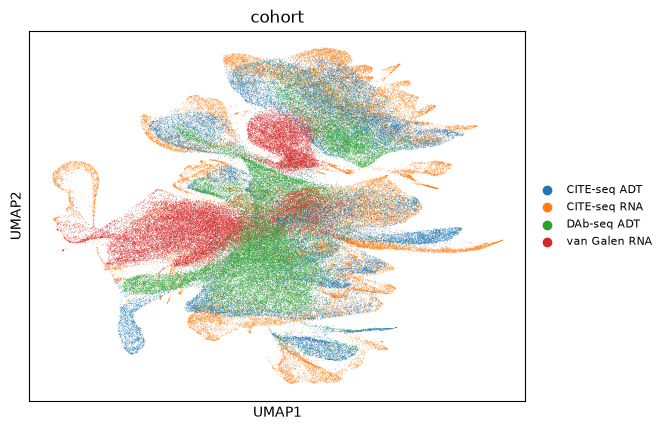

In [9]:
bridge_blocks = [
    ("CITE-seq RNA", "rna", cite["rna"]),
    ("CITE-seq ADT", "adt", cite["adt"]),
    ("van Galen RNA", "rna", vg_pp),
    ("DAb-seq ADT", "adt", dab_pp),
]

joint_pre = stack_embeddings(
    model,
    bridge_blocks,
    device=device,
)

sc.pp.neighbors(
    joint_pre,
    use_rep="X_univi",
    n_neighbors=30,
)
sc.tl.umap(
    joint_pre,
    random_state=0,
)

sc.pl.umap(
    joint_pre,
    color=["cohort"],
    legend_fontsize=8,
)

## Mutation labels from the original cohort metadata

**van Galen:** mutation truth is reconstructed from `MutTranscripts` and `WtTranscripts`. A cell is labeled mutant when the mutant transcript string contains the gene and the wild-type string does not; wild type is assigned when the reverse is true; otherwise the gene is masked for that cell.

**DAb-seq:** the original Demaree `.h5ad` objects do **not** use synthetic `mut_<GENE>` columns. Their genotype calls are stored in variant-specific `.obs` columns such as `NPM1 W288fs`, `DNMT3A R882H`, and `FLT3-ITD`. The code below discovers those columns and collapses them to gene-level 0/1/NA targets.

DAb directly contributes labels only for `NPM1`, `DNMT3A`, and `FLT3`; the remaining genes stay masked for DAb rather than being interpreted as wild type.

In [10]:
def vg_labels(obs, gene):
    gene_u = str(gene).upper()

    mut = (
        obs["MutTranscripts"]
        .fillna("")
        .astype(str)
        .str.upper()
        .str.contains(gene_u, regex=False)
    )
    wt = (
        obs["WtTranscripts"]
        .fillna("")
        .astype(str)
        .str.upper()
        .str.contains(gene_u, regex=False)
    )

    y = np.full(len(obs), np.nan, dtype=np.float32)
    y[(mut & ~wt).to_numpy()] = 1.0
    y[(wt & ~mut).to_numpy()] = 0.0
    return y


def mutation_columns_for_gene(obs, gene):
    """Find DAb variant columns containing the gene as a token."""
    gene = str(gene).upper()
    pattern = re.compile(
        rf"(?<![A-Z0-9]){re.escape(gene)}(?![A-Z0-9])",
        flags=re.IGNORECASE,
    )

    hits = [
        col
        for col in obs.columns
        if pattern.search(str(col).upper())
    ]

    # Prefer the manuscript variants when several annotations exist.
    preference = {
        "NPM1": ["W288"],
        "DNMT3A": ["R882"],
        "FLT3": ["ITD"],
    }.get(gene, [])

    preferred = [
        col
        for col in hits
        if any(
            token in str(col).upper()
            for token in preference
        )
    ]

    return preferred if preferred else hits


def coerce_variant_call(series):
    """
    DAb mutation columns are treated as:
      missing -> NA
      zero/false/WT -> 0
      nonzero/true/mutant -> 1
    """
    s = pd.Series(series, index=series.index)

    if pd.api.types.is_bool_dtype(s):
        return s.astype(float).to_numpy()

    numeric = pd.to_numeric(s, errors="coerce")

    out = np.full(len(s), np.nan, dtype=np.float32)
    numeric_ok = numeric.notna().to_numpy()

    if numeric_ok.any():
        values = numeric.to_numpy(dtype=float)
        out[numeric_ok] = (
            values[numeric_ok] != 0
        ).astype(np.float32)

    # Fill still-unparsed string labels.
    unresolved = ~numeric_ok & s.notna().to_numpy()
    if unresolved.any():
        text = (
            s.astype("string")
            .str.strip()
            .str.lower()
        )

        wt_tokens = {
            "wt",
            "wildtype",
            "wild-type",
            "false",
            "negative",
            "neg",
            "no",
        }
        mut_tokens = {
            "mut",
            "mutant",
            "true",
            "positive",
            "pos",
            "yes",
        }

        for i in np.flatnonzero(unresolved):
            value = text.iloc[i]
            if value in wt_tokens:
                out[i] = 0.0
            elif value in mut_tokens:
                out[i] = 1.0

    return out


def dab_gene_label(obs, gene):
    cols = mutation_columns_for_gene(obs, gene)

    if not cols:
        return np.full(len(obs), np.nan, dtype=np.float32), []

    calls = np.column_stack(
        [
            coerce_variant_call(obs[col])
            for col in cols
        ]
    )

    labeled = np.isfinite(calls).any(axis=1)
    positive = np.nan_to_num(
        calls,
        nan=0.0,
    ).max(axis=1) > 0

    y = np.full(len(obs), np.nan, dtype=np.float32)
    y[labeled] = positive[labeled].astype(np.float32)

    return y, cols


labels = {
    "vg": {
        gene: vg_labels(vg_pp.obs, gene)
        for gene in GENES
    },
    "dab": {},
}

dab_gene_columns = {}

for gene in GENES:
    if gene in DAB_GENES:
        y, cols = dab_gene_label(
            dab_pp.obs,
            gene,
        )
        labels["dab"][gene] = y
        dab_gene_columns[gene] = cols

        # Canonical convenience column for downstream API code.
        dab_pp.obs[f"mut_{gene}"] = y
    else:
        labels["dab"][gene] = np.full(
            dab_pp.n_obs,
            np.nan,
            dtype=np.float32,
        )
        dab_gene_columns[gene] = []


print("DAb genotype source columns:")
for gene in DAB_GENES:
    print(
        f"  {gene:7s}: "
        f"{dab_gene_columns[gene] or 'NOT FOUND'}"
    )

missing_dab_genes = [
    gene
    for gene in DAB_GENES
    if not dab_gene_columns[gene]
]

if missing_dab_genes:
    candidates = [
        col
        for col in dab_pp.obs.columns
        if any(
            token in str(col).upper()
            for token in [
                "NPM1",
                "DNMT3A",
                "FLT3",
                "ITD",
                "R882",
                "W288",
            ]
        )
    ]

    raise KeyError(
        "The hosted DAb object is missing genotype columns "
        f"for {missing_dab_genes}. This is a data-release problem, "
        "not a modeling problem. Mutation-like columns currently "
        f"visible are: {candidates}"
    )


counts = pd.DataFrame(
    {
        (cohort, state): {
            gene: int(
                np.nansum(
                    labels[cohort][gene] == value
                )
            )
            for gene in GENES
        }
        for cohort in labels
        for state, value in [
            ("mut", 1.0),
            ("wt", 0.0),
        ]
    }
)

print("\nObserved mutation-label counts:")
display(counts)

DAb genotype source columns:
  NPM1   : ['NPM1 W288fs']
  DNMT3A : ['DNMT3A R882H']
  FLT3   : ['FLT3-ITD']

Observed mutation-label counts:


vg          dab       
        mut    wt    mut     wt
NPM1    415  1503  24272  15967
DNMT3A  145   420  25895  14344
FLT3     38   128  10279   8008
TP53     52    26      0      0
NRAS     36   117      0      0
TET2     17    31      0      0
IDH2      3   237      0      0

## Group-aware mutation-head refinement

The article evaluated mutation heads with cell-level splits because of metadata constraints, and noted that patient-level claims would need patient-held-out evaluation. Here, van Galen is split by patient/sample identity and DAb by experiment/source identity, so the test groups are never seen by the refiner. This asks more than the published analysis did. The test groups are never supplied to the refiner.

Each binary mutation head is warmed up with frozen encoders and then refined with the RNA and ADT encoders at a small learning rate. The CITE bridge training set is replayed during refinement to preserve the original cross-modal geometry.


In [11]:
def first_existing_column(obs, candidates):
    for col in candidates:
        if col in obs.columns:
            return col
    return None

VG_GROUP_COL = first_existing_column(
    vg_pp.obs,
    [
        "patient",
        "orig.ident",
        "sample_id",
        "sample",
        "donor",
    ],
)

DAB_GROUP_COL = first_existing_column(
    dab_pp.obs,
    [
        "experiment",
        "dab_source",
        "sample_id",
        "patient",
    ],
)

print("van Galen grouping column:", VG_GROUP_COL)
print("DAb grouping column:", DAB_GROUP_COL)

def group_split_masks(
    adata,
    group_col,
    *,
    seed=42,
    fractions=(0.70, 0.15, 0.15),
):
    """
    Deterministic group-level 70/15/15 split.
    Falls back to cell-level only if no grouping column exists.
    """
    n = adata.n_obs
    if group_col is None:
        rng = np.random.default_rng(seed)
        idx = rng.permutation(n)
        n_train = int(fractions[0] * n)
        n_val = int(fractions[1] * n)
        masks = {
            "train": np.zeros(n, dtype=bool),
            "val": np.zeros(n, dtype=bool),
            "test": np.zeros(n, dtype=bool),
        }
        masks["train"][idx[:n_train]] = True
        masks["val"][idx[n_train:n_train + n_val]] = True
        masks["test"][idx[n_train + n_val:]] = True
        print(
            "WARNING: no grouping column available; "
            "using a cell-level split."
        )
        return masks

    groups = (
        adata.obs[group_col]
        .astype(str)
        .fillna("NA")
        .to_numpy()
    )
    unique = np.unique(groups)
    if len(unique) < 3:
        raise ValueError(
            f"{group_col!r} contains only {len(unique)} groups; "
            "cannot form leakage-aware train/val/test splits."
        )
    rng = np.random.default_rng(seed)
    unique = rng.permutation(unique)
    n_groups = len(unique)
    n_test = max(1, int(round(fractions[2] * n_groups)))
    n_val = max(1, int(round(fractions[1] * n_groups)))
    # Always leave at least one training group.
    if n_test + n_val >= n_groups:
        n_test = 1
        n_val = 1
    test_groups = unique[:n_test]
    val_groups = unique[n_test:n_test + n_val]
    train_groups = unique[n_test + n_val:]
    masks = {
        "train": np.isin(groups, train_groups),
        "val": np.isin(groups, val_groups),
        "test": np.isin(groups, test_groups),
    }
    print(
        f"{group_col}: "
        f"{len(train_groups)} train groups, "
        f"{len(val_groups)} val groups, "
        f"{len(test_groups)} test groups"
    )
    return masks

split_masks = {
    "vg": group_split_masks(
        vg_pp,
        VG_GROUP_COL,
        seed=42,
    ),
    "dab": group_split_masks(
        dab_pp,
        DAB_GROUP_COL,
        seed=43,
    ),
}

def labeled_counts_for_mask(cohort, gene, mask):
    y = labels[cohort][gene]
    usable = mask & np.isfinite(y)
    return (
        int(np.sum(y[usable] == 0)),
        int(np.sum(y[usable] == 1)),
    )

# Instantiate heads only when the combined TRAINING data have
# sufficient wild-type and mutant examples.
heads = []

for gene in GENES:
    train_wt = 0
    train_mut = 0
    for cohort in ("vg", "dab"):
        wt, mut = labeled_counts_for_mask(
            cohort,
            gene,
            split_masks[cohort]["train"],
        )
        train_wt += wt
        train_mut += mut
    if (
        train_wt >= MIN_PER_CLASS
        and train_mut >= MIN_PER_CLASS
    ):
        heads.append(gene)
print("heads trained for:", heads)

coverage_rows = []
for cohort in ("vg", "dab"):
    for split_name in ("train", "val", "test"):
        for gene in GENES:
            wt, mut = labeled_counts_for_mask(
                cohort,
                gene,
                split_masks[cohort][split_name],
            )
            coverage_rows.append(
                {
                    "cohort": cohort,
                    "split": split_name,
                    "gene": gene,
                    "wt": wt,
                    "mut": mut,
                    "labeled": wt + mut,
                }
            )

coverage = pd.DataFrame(coverage_rows)
display(
    coverage.pivot_table(
        index=["cohort", "gene"],
        columns="split",
        values=["wt", "mut"],
        aggfunc="sum",
        fill_value=0,
    )
)

def subset_with_labels(
    adata,
    modality,
    cohort,
    split_name,
):
    mask = split_masks[cohort][split_name]
    idx = np.flatnonzero(mask)
    subset = adata[idx].copy()
    y = {
        f"mut_{gene}": np.where(
            np.isfinite(labels[cohort][gene][idx]),
            labels[cohort][gene][idx],
            -1,
        ).astype(np.float32)
        for gene in heads
    }
    return subset, y

vg_train, y_vg_train = subset_with_labels(vg_pp, "rna", "vg", "train",)
vg_val, y_vg_val = subset_with_labels(vg_pp, "rna", "vg", "val",)
dab_train, y_dab_train = subset_with_labels(dab_pp, "adt", "dab", "train",)
dab_val, y_dab_val = subset_with_labels(dab_pp, "adt", "dab", "val",)

for gene in heads:
    model.add_classification_head(
        ClassHeadConfig(
            f"mut_{gene}",
            n_classes=2,
            head_type="binary",
            hidden_dims=[64, 32],
            dropout=0.1,
            batchnorm=False,
            layernorm=True,
        ),
        label_names=["wt", "mut"],
    )

refiner = (
    UniVIRefiner(
        model,
        [
            make_loader(
                {"rna": vg_train},
                labels=y_vg_train,
                batch_size=256,
                shuffle=True,
            ),
            make_loader(
                {"adt": dab_train},
                labels=y_dab_train,
                batch_size=256,
                shuffle=True,
            ),
        ],
        [
            make_loader(
                {"rna": vg_val},
                labels=y_vg_val,
                batch_size=1024,
            ),
            make_loader(
                {"adt": dab_val},
                labels=y_dab_val,
                batch_size=1024,
            ),
        ],
        device=device,
        encoder_modalities=["rna", "adt"],
        replay_loader=make_loader(
            cite_train,
            batch_size=256,
            shuffle=True,
            drop_last=True,
        ),
        config=RefinementConfig(
            max_epochs=REFINE_EPOCHS,
            warmup_epochs=min(
                50,
                REFINE_EPOCHS,
            ),
            lr_head=2e-4,
            lr_encoder=1e-5,
            latent_weight=1.0,
            replay_weight=1.0,
            patience=40,
            log_every=50,
        ),
    )
    if heads
    else None
)

if refiner is not None:
    # Capture the return value so the full history dictionary is not
    # rendered into the ReadTheDocs page.
    refinement_result = refiner.fit()
    history = (
        refinement_result.get("history", [])
        if isinstance(refinement_result, dict)
        else []
    )
    if history:
        last = history[-1]
        print(
            "Mutation refinement complete: "
            f"{len(history)} epochs; "
            f"final stage={last.get('stage')}; "
            f"final val loss="
            f"{last.get('val_supervised_loss', float('nan')):.4f}"
        )
    else:
        print("Mutation refinement complete.")

van Galen grouping column: orig.ident
DAb grouping column: experiment
orig.ident: 29 train groups, 6 val groups, 6 test groups
experiment: 6 train groups, 1 val groups, 1 test groups
heads trained for: ['NPM1', 'DNMT3A', 'FLT3', 'NRAS']


mut                wt             
split          test  train  val  test  train   val
cohort gene                                       
dab    DNMT3A  4227  21204  464   795  11712  1837
       FLT3    4678   5601    0   344   5363  2301
       IDH2       0      0    0     0      0     0
       NPM1    3952  20305   15  1070  12611  2286
       NRAS       0      0    0     0      0     0
       TET2       0      0    0     0      0     0
       TP53       0      0    0     0      0     0
vg     DNMT3A     5    122   18   174    223    23
       FLT3       0     12   26    14     10   104
       IDH2       0      3    0   189     46     2
       NPM1       0    336   79   115   1246   142
       NRAS       0     36    0     5    112     0
       TET2       0     17    0     0     31     0
       TP53      23      8   21     8     18     0

Refinement 0: heads, validation=0.56055
Refinement 50: encoders+heads, validation=0.53104
Mutation refinement complete: 90 epochs; final stage=encoders+heads; final val loss=0.7042


In [12]:
def positive_probability(p):
    p = np.asarray(p)
    return p.reshape(len(p), -1)[:, -1]

cohort_objects = {
    "vg": (vg_pp, "rna"),
    "dab": (dab_pp, "adt"),
    "cite_rna": (cite["rna"], "rna"),
    "cite_adt": (cite["adt"], "adt"),
}
probabilities = {}

for cohort, (adata, modality) in cohort_objects.items():
    out = (
        predict_heads_adata(
            model,
            adata,
            modality,
            device=device,
        )
        if heads
        else {}
    )
    for gene in heads:
        probabilities[(cohort, gene)] = positive_probability(
            out[f"mut_{gene}"]
        )

# Evaluate only on held-out labeled cells from the two cohorts
# that contain mutation truth.
rows = []
for cohort in ("vg", "dab"):
    for gene in heads:
        y = labels[cohort][gene]
        test = (
            split_masks[cohort]["test"]
            & np.isfinite(y)
        )
        if (
            test.sum() > 0
            and len(np.unique(y[test])) == 2
        ):
            p = probabilities[(cohort, gene)]
            rows.append(
                {
                    "cohort": cohort,
                    "gene": gene,
                    "n_test": int(test.sum()),
                    "AUC": roc_auc_score(
                        y[test],
                        p[test],
                    ),
                    "AP": average_precision_score(
                        y[test],
                        p[test],
                    ),
                }
            )

metrics = pd.DataFrame(rows).sort_values(
    ["gene", "cohort"]
)
display(metrics.round(3))

,cohort,gene,n_test,AUC,AP
2,dab,DNMT3A,5022,0.566,0.859
0,vg,DNMT3A,179,0.749,0.066
3,dab,FLT3,5022,0.706,0.957
1,dab,NPM1,5022,0.535,0.801


## Refined joint latent and mutation probabilities

After mutation refinement, the embeddings are recomputed for all four blocks. Head probabilities are shown across CITE RNA, CITE ADT, van Galen RNA, and DAb ADT.

For the NPM1 example, observed source-cohort mutation truth is also overlaid where available; CITE remains unlabeled.

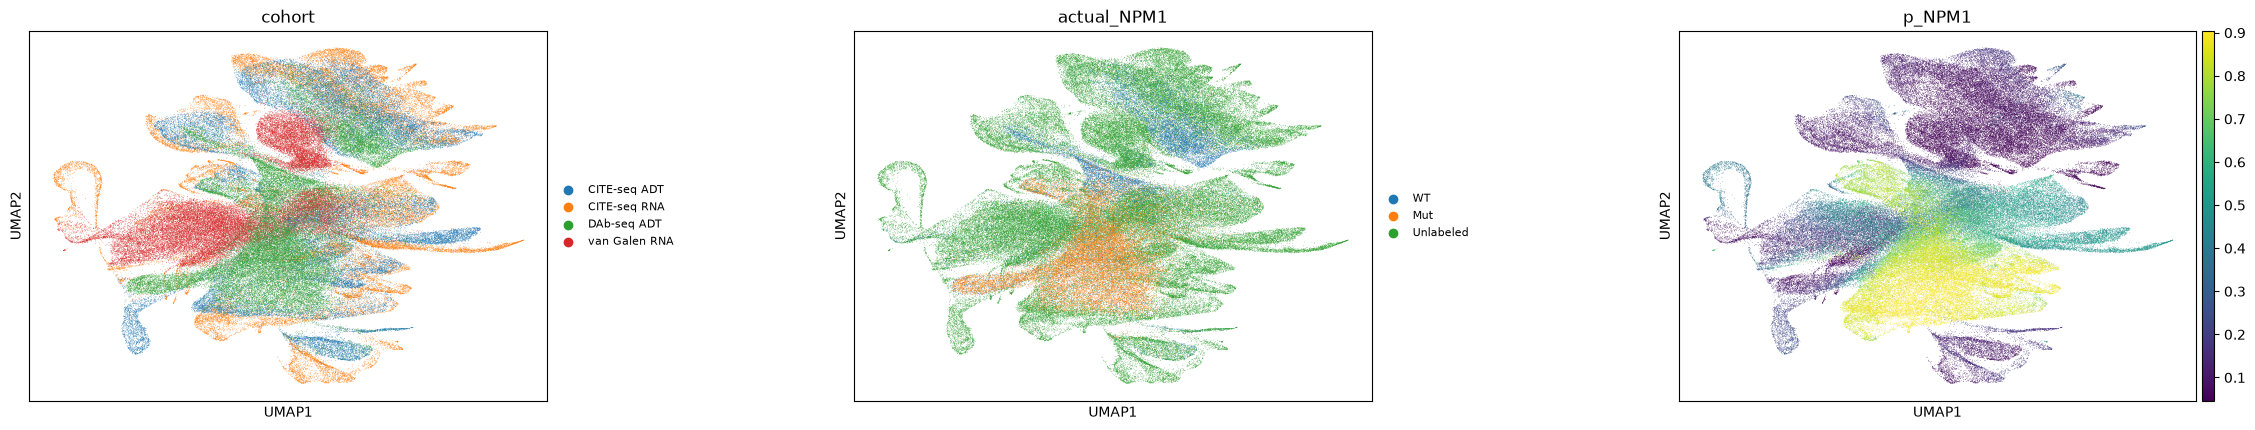

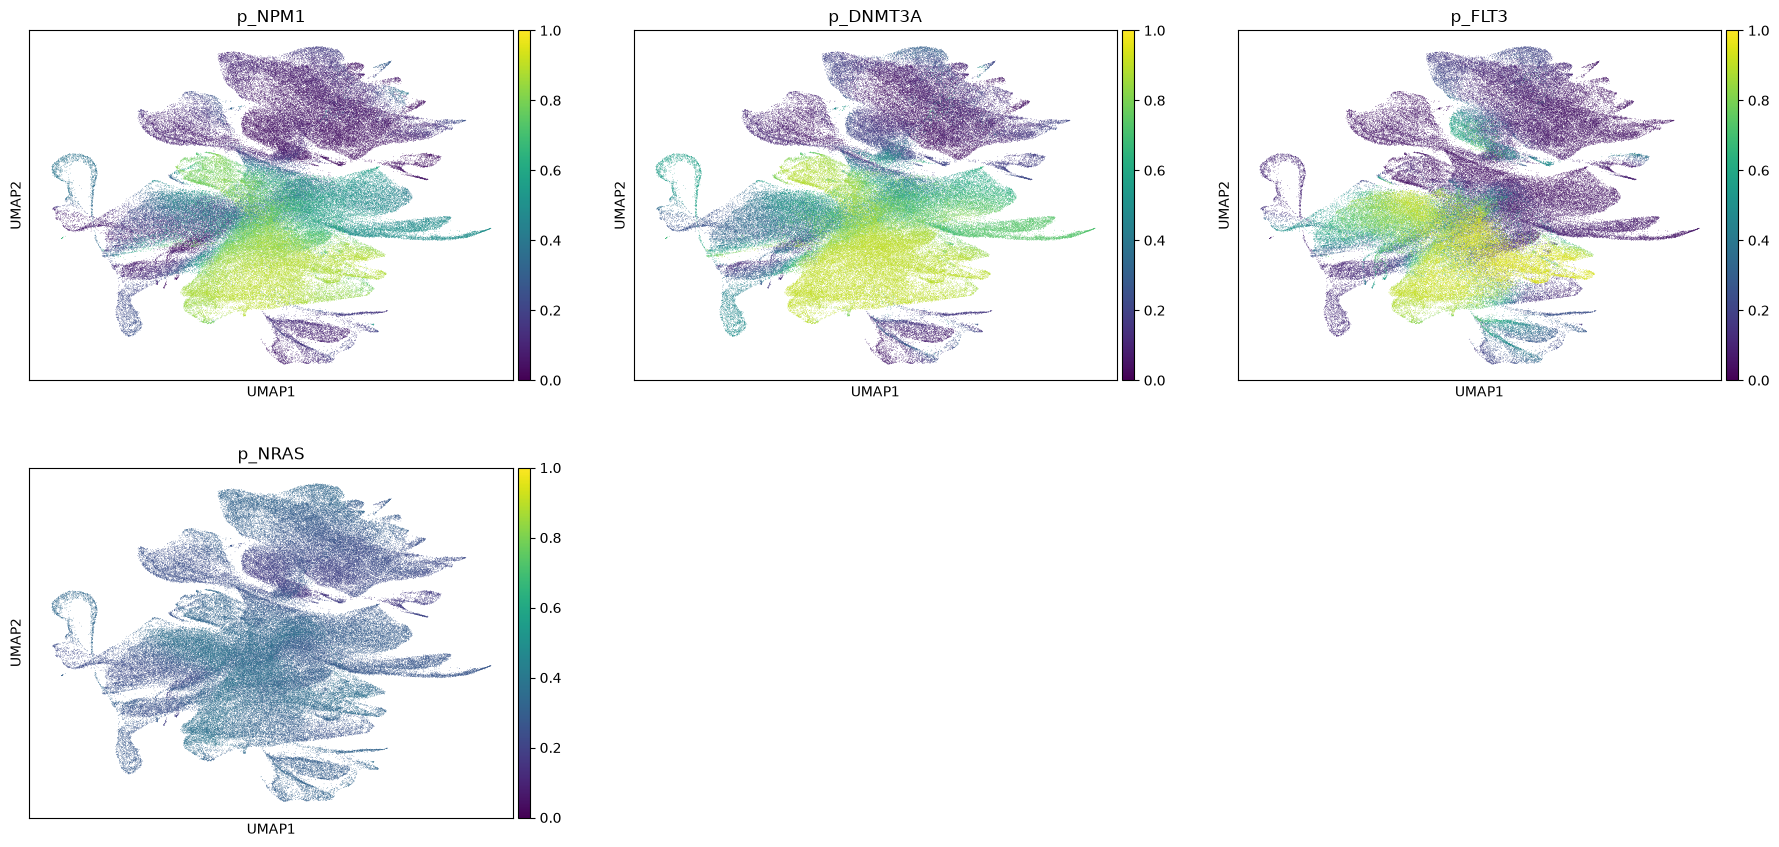

In [13]:
joint_post = stack_embeddings(
    model,
    bridge_blocks,
    device=device,
)

# stack_embeddings follows bridge_blocks order:
# CITE RNA, CITE ADT, van Galen RNA, DAb ADT.
block_sizes = [
    cite["rna"].n_obs,
    cite["adt"].n_obs,
    vg_pp.n_obs,
    dab_pp.n_obs,
]

for gene in heads:
    joint_post.obs[f"p_{gene}"] = np.concatenate(
        [
            probabilities[("cite_rna", gene)],
            probabilities[("cite_adt", gene)],
            probabilities[("vg", gene)],
            probabilities[("dab", gene)],
        ]
    )

# Observed HERO truth exists only for van Galen and DAb.
hero_truth = np.concatenate(
    [
        np.full(cite["rna"].n_obs, np.nan),
        np.full(cite["adt"].n_obs, np.nan),
        labels["vg"][HERO],
        labels["dab"][HERO],
    ]
)

hero_label = np.full(
    len(hero_truth),
    "Unlabeled",
    dtype=object,
)
hero_label[np.isfinite(hero_truth) & (hero_truth == 0)] = "WT"
hero_label[np.isfinite(hero_truth) & (hero_truth == 1)] = "Mut"

joint_post.obs[f"actual_{HERO}"] = pd.Categorical(
    hero_label,
    categories=["WT", "Mut", "Unlabeled"],
)

sc.pp.neighbors(
    joint_post,
    use_rep="X_univi",
    n_neighbors=30,
)
sc.tl.umap(
    joint_post,
    random_state=0,
)
sc.pl.umap(
    joint_post,
    color=[
        "cohort",
        f"actual_{HERO}",
        f"p_{HERO}",
    ],
    wspace=0.45,
    legend_fontsize=8,
    cmap="viridis",
)

if heads:
    sc.pl.umap(
        joint_post,
        color=[f"p_{gene}" for gene in heads],
        ncols=3,
        cmap="viridis",
        vmin=0,
        vmax=1,
    )